<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/Preparing_Non_Uniform_Time_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
#import tick customization tools
import matplotlib.ticker as mticks
import matplotlib.dates as mdates
## Setting figures to timeseries-friendly
plt.rcParams['figure.figsize'] = (12,4)
plt.rcParams['figure.facecolor'] = 'white'
sns.set_context("talk", font_scale=0.9)
# set random seed
SEED = 321
np.random.seed(SEED)
#display more columns
pd.set_option('display.max_columns',50)

In [ ]:
import pandas as pd

url = "Part1_Crime_Beta_3880953751259285714.csv"
df = pd.read_csv(url, low_memory=False)

df.head()

,RowID,CCNumber,CrimeDateTime,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,...,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
0,1,14I10336,8/29/2014 12:00:00 PM,5A,BURGLARY,NaN,NaN,835.0,M,52.0,...,SOUTHWEST,NaN,SHIPLEY HILL,39.288352,-76.660731,"(39.288352111548775,-76.660731200606335)",ROW/TOWNHOUSE-VAC,1.0,-76.660731,39.288352
1,2,14H13075,8/29/2014 11:45:00 PM,4E,COMMON ASSAULT,NaN,NaN,515.0,F,24.0,...,NORTHERN,NaN,WAVERLY,39.335514,-76.607897,"(39.335514488267016,-76.60789683728612)",ROW/TOWNHOUSE-OCC,1.0,-76.607897,39.335514
2,3,14H13066,8/29/2014 11:10:00 PM,6G,LARCENY,NaN,NaN,114.0,F,44.0,...,CENTRAL,NaN,DOWNTOWN,39.292553,-76.618255,"(39.292552601970897,-76.618254674552134)",BAR,1.0,-76.618255,39.292553
3,4,14I00593,8/29/2014 7:00:00 AM,6J,LARCENY,NaN,NaN,732.0,NaN,NaN,...,WESTERN,NaN,PARKVIEW/WOODBROOK,39.316814,-76.649890,"(39.316813840390076,-76.649889876952656)",STREET,1.0,-76.649890,39.316814
4,5,14H13360,8/29/2014 11:30:00 PM,6G,LARCENY,NaN,NaN,213.0,F,26.0,...,SOUTHEAST,NaN,FELLS POINT,39.280805,-76.594750,"(39.28080478810265,-76.594749640946659)",BAR,1.0,-76.594750,39.280805


In [ ]:
test_date = df.loc[0, 'CrimeDateTime']
test_date

'8/29/2014 12:00:00 PM'

In [ ]:
test_datetime = pd.to_datetime(test_date)
test_datetime

Timestamp('2014-08-29 12:00:00')

In [ ]:
df['CrimeDateTime'] = pd.to_datetime(df['CrimeDateTime'])

In [ ]:
df['CrimeDateTime'] = pd.to_datetime(df['CrimeDateTime'],errors='coerce')

In [ ]:
# how many null values did we create?
df['CrimeDateTime'].isna().sum()

np.int64(0)

In [ ]:
# drop the single erroneous time
df = df.dropna(subset=['CrimeDateTime'])
df['CrimeDateTime'].isna().sum()

np.int64(0)

In [ ]:
## now that we remove NaT's let's make our datetime index
df = df.set_index('CrimeDateTime')
df.head(3)

,RowID,CCNumber,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,,
2014-08-29 12:00:00,1,14I10336,5A,BURGLARY,NaN,NaN,835.0,M,52.0,UNKNOWN,NaN,2700 W FAIRMOUNT AVE,SOUTHWEST,NaN,SHIPLEY HILL,39.288352,-76.660731,"(39.288352111548775,-76.660731200606335)",ROW/TOWNHOUSE-VAC,1.0,-76.660731,39.288352
2014-08-29 23:45:00,2,14H13075,4E,COMMON ASSAULT,NaN,NaN,515.0,F,24.0,BLACK_OR_AFRICAN_AMERICAN,NaN,500 E 38TH ST,NORTHERN,NaN,WAVERLY,39.335514,-76.607897,"(39.335514488267016,-76.60789683728612)",ROW/TOWNHOUSE-OCC,1.0,-76.607897,39.335514
2014-08-29 23:10:00,3,14H13066,6G,LARCENY,NaN,NaN,114.0,F,44.0,BLACK_OR_AFRICAN_AMERICAN,NaN,200 PARK AVE,CENTRAL,NaN,DOWNTOWN,39.292553,-76.618255,"(39.292552601970897,-76.618254674552134)",BAR,1.0,-76.618255,39.292553


In [ ]:
df = df.sort_index()
df.index

DatetimeIndex(['2011-02-12 05:00:00', '2011-02-13 01:20:00',
               '2011-04-25 01:25:00', '2011-10-16 11:40:00',
               '2011-11-02 14:30:00', '2012-01-04 12:15:00',
               '2012-02-28 00:00:00', '2012-02-28 01:10:00',
               '2012-02-28 01:45:00', '2012-02-28 02:30:00',
               ...
               '2016-05-01 14:45:00', '2016-05-01 15:00:00',
               '2016-05-01 18:00:00', '2016-05-01 18:20:00',
               '2016-05-01 19:00:00', '2016-05-01 19:00:00',
               '2016-05-01 20:45:00', '2016-05-01 21:20:00',
               '2016-05-01 21:45:00', '2016-05-01 21:50:00'],
              dtype='datetime64[ns]', name='CrimeDateTime', length=97406, freq=None)

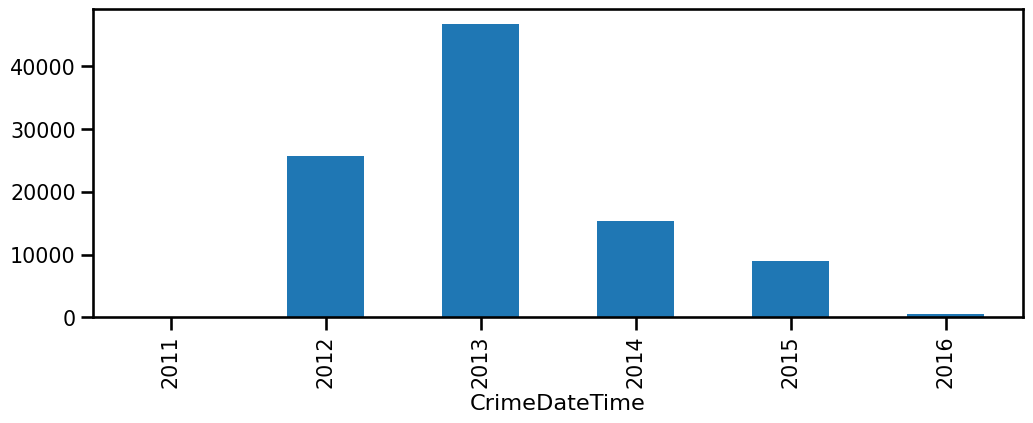

In [ ]:
years = df.index.year
years.value_counts().sort_index().plot(kind='bar');

In [ ]:
## keeping 2011 to present
df = df.loc['2011':]
df.index

DatetimeIndex(['2011-02-12 05:00:00', '2011-02-13 01:20:00',
               '2011-04-25 01:25:00', '2011-10-16 11:40:00',
               '2011-11-02 14:30:00', '2012-01-04 12:15:00',
               '2012-02-28 00:00:00', '2012-02-28 01:10:00',
               '2012-02-28 01:45:00', '2012-02-28 02:30:00',
               ...
               '2016-05-01 14:45:00', '2016-05-01 15:00:00',
               '2016-05-01 18:00:00', '2016-05-01 18:20:00',
               '2016-05-01 19:00:00', '2016-05-01 19:00:00',
               '2016-05-01 20:45:00', '2016-05-01 21:20:00',
               '2016-05-01 21:45:00', '2016-05-01 21:50:00'],
              dtype='datetime64[ns]', name='CrimeDateTime', length=97406, freq=None)

<Axes: ylabel='Description'>

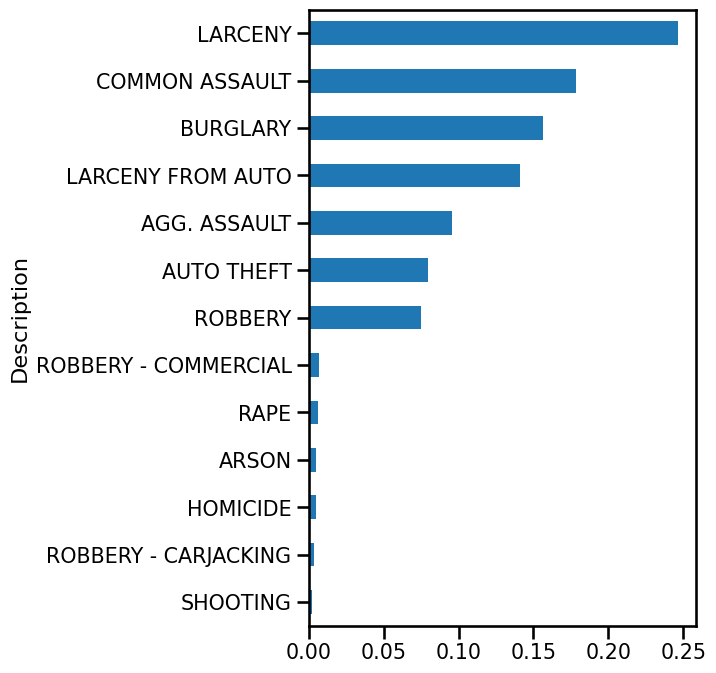

In [ ]:
## Inspect the value_counts for the different types of crimes
crime_counts = df['Description'].value_counts(normalize=True)
crime_counts.sort_values().plot(kind='barh',figsize=(5,8))

In [ ]:
## Inspect the value_counts for the different types of crimes
crime_counts = df['Description'].value_counts().to_frame('Total # of Crimes')
crime_counts

,Total # of Crimes
Description,
LARCENY,24012
COMMON ASSAULT,17389
BURGLARY,15210
LARCENY FROM AUTO,13722
AGG. ASSAULT,9340
AUTO THEFT,7741
ROBBERY,7282
ROBBERY - COMMERCIAL,649
RAPE,576


In [ ]:
# display with an inline-barplot inside your df
crime_counts.style.bar('Total # of Crimes')

,Total # of Crimes
Description,
LARCENY,24012
COMMON ASSAULT,17389
BURGLARY,15210
LARCENY FROM AUTO,13722
AGG. ASSAULT,9340
AUTO THEFT,7741
ROBBERY,7282
ROBBERY - COMMERCIAL,649
RAPE,576


##Using Dictionaries and Loops to Prepare Time Series

In [ ]:
## demoing groupby with .counts() vs .size()
df.groupby("Description").count().head()

,RowID,CCNumber,CrimeCode,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
Description,,,,,,,,,,,,,,,,,,,,,
AGG. ASSAULT,9340,9340,9340,0,9340,9148,9307,8767,9340,0,9294,9149,0,9150,9307,9307,9340,9023,9339,9306,9306
ARSON,479,479,479,0,479,468,397,298,479,0,476,468,0,468,476,476,479,468,479,476,476
AUTO THEFT,7741,7741,7741,0,0,7566,7255,6948,7740,2,7684,7566,0,7567,7701,7701,7741,7592,7741,7701,7701
BURGLARY,15210,15210,15210,0,0,15101,13088,11288,15209,0,15189,15101,0,15101,15190,15190,15210,15050,15210,15190,15190
COMMON ASSAULT,17389,17389,17389,0,3,17157,17350,15997,17389,2,17302,17157,0,17154,17346,17346,17389,16945,17389,17346,17346


In [ ]:
df.groupby("Description").size().head()

,0
Description,
AGG. ASSAULT,9340
ARSON,479
AUTO THEFT,7741
BURGLARY,15210
COMMON ASSAULT,17389


##Testing 1 crime first

In [ ]:
## making our dictionary
CRIMES = {}

In [ ]:
## Lets test 1 crime before we create our loop
crime ='ROBBERY'
crime

'ROBBERY'

In [ ]:
# I. Save a temp df of just the rows that match the crime
temp = df.loc[ df['Description']==crime]
temp.head(3)

,RowID,CCNumber,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,,
2012-02-28 14:06:00,96121,12B11994,3B,ROBBERY,NaN,NaN,613.0,F,34.0,WHITE,NaN,4800 SNADER AVE,NORTHWEST,NaN,LUCILLE PARK,39.340855,-76.677361,"(39.340855051028718,-76.677361348595838)",STREET,1.0,-76.677361,39.340855
2012-02-28 22:02:00,96764,12B12191,3AO,ROBBERY,NaN,OTHER,432.0,NaN,NaN,UNKNOWN,NaN,3400 BELAIR RD,NORTHEAST,NaN,BELAIR-EDISON,39.322656,-76.572628,"(39.322656233903103,-76.572627971690039)",STREET,1.0,-76.572628,39.322656
2012-02-29 11:04:00,95257,12C14230,3B,ROBBERY,NaN,NaN,623.0,M,NaN,BLACK_OR_AFRICAN_AMERICAN,NaN,3800 BELLE AVE,NORTHWEST,NaN,CALLAWAY-GARRISON,39.333620,-76.678838,"(39.333619678544743,-76.678838051656371)",NaN,1.0,-76.678838,39.333620


In [ ]:
# II. Resample the temp DataFrame as Daily data (crime counts)
# and keep ONLY the .size()
temp_res = temp.resample("D").size()
temp_res

,0
CrimeDateTime,
2012-02-28,2
2012-02-29,2
2012-03-01,2
2012-03-02,8
2012-03-03,0
...,...
2016-04-27,0
2016-04-28,0
2016-04-29,0


In [ ]:
#III. Save the temporary DataFrame in the dictionary, #using the crime description as the key.
CRIMES[crime] = temp_res.copy()
CRIMES.keys()

dict_keys(['ROBBERY'])

In [ ]:
CRIMES['ROBBERY']

,0
CrimeDateTime,
2012-02-28,2
2012-02-29,2
2012-03-01,2
2012-03-02,8
2012-03-03,0
...,...
2016-04-27,0
2016-04-28,0
2016-04-29,0


##Making Our Loop

In [ ]:
# 1. get list of  unique crime descriptions
crime_list = df['Description'].unique()
crime_list

array(['BURGLARY', 'COMMON ASSAULT', 'LARCENY', 'LARCENY FROM AUTO',
       'AUTO THEFT', 'AGG. ASSAULT', 'ROBBERY', 'ROBBERY - COMMERCIAL',
       'ARSON', 'RAPE', 'HOMICIDE', 'ROBBERY - CARJACKING', 'SHOOTING'],
      dtype=object)

In [ ]:
# 2. Create an empty dictionary
CRIMES = {}
# 3. Loop through the list of crimes
for crime in crime_list:
    # I. Save a temp df of just the rows that match the crime
   temp = df.loc[ df['Description']==crime].copy()
    # II. Resample the temp DataFrame as Daily data (crime counts)
    # and keep ONLY the .size()
   temp_res = temp.resample("D").size()
   #III. Save the temporary DataFrame in the dictionary,
   #using the crime description as the key.
   CRIMES[crime] = temp_res.copy()
CRIMES.keys()

dict_keys(['BURGLARY', 'COMMON ASSAULT', 'LARCENY', 'LARCENY FROM AUTO', 'AUTO THEFT', 'AGG. ASSAULT', 'ROBBERY', 'ROBBERY - COMMERCIAL', 'ARSON', 'RAPE', 'HOMICIDE', 'ROBBERY - CARJACKING', 'SHOOTING'])

In [ ]:
CRIMES['SHOOTING']

,0
CrimeDateTime,
2012-07-31,2
2012-08-01,0
2012-08-02,0
2012-08-03,1
2012-08-04,0
...,...
2016-04-17,0
2016-04-18,0
2016-04-19,0


##Convert Dictionary to DataFrame

In [ ]:
crimes_df = pd.DataFrame(CRIMES)
crimes_df

,BURGLARY,COMMON ASSAULT,LARCENY,LARCENY FROM AUTO,AUTO THEFT,AGG. ASSAULT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,RAPE,HOMICIDE,ROBBERY - CARJACKING,SHOOTING
CrimeDateTime,,,,,,,,,,,,,
2011-02-12,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-02-13,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-02-14,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-02-15,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-02-16,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-27,0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-28,0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-29,0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
## saving to disk for later
crimes_df.to_csv("baltimore_crime_counts_2023.csv")